### PROYECTO - **Análisis y Visualización de Recetas de Cerveza Artesanal**


- Galindo Espinosa Ana Lilia
- Herrera Moreno Sayuri 


**1. CARGA Y EVALUCIÓN DE DATOS**

In [47]:
## Carga de librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [48]:
## Evaluación inicial del dataset

df = pd.read_csv("datasets/recipeData1.csv", encoding="latin1")
df.shape

(73861, 23)

In [49]:
df.head()

,BeerID,Name,URL,Style,StyleID,Size(L),OG,FG,ABV,IBU,...,BoilGravity,Efficiency,MashThickness,SugarScale,BrewMethod,PitchRate,PrimaryTemp,PrimingMethod,PrimingAmount,UserId
0,1,Vanilla Cream Ale,/homebrew/recipe/view/1633/vanilla-cream-ale,Cream Ale,45,21.77,1.055,1.013,5.48,17.65,...,1.038,70.0,NaN,Specific Gravity,All Grain,NaN,17.78,corn sugar,4.5 oz,116.0
1,2,Southern Tier Pumking clone,/homebrew/recipe/view/16367/southern-tier-pumk...,Holiday/Winter Special Spiced Beer,85,20.82,1.083,1.021,8.16,60.65,...,1.070,70.0,NaN,Specific Gravity,All Grain,NaN,NaN,NaN,NaN,955.0
2,3,Zombie Dust Clone - EXTRACT,/homebrew/recipe/view/5920/zombie-dust-clone-e...,American IPA,7,18.93,1.063,1.018,5.91,59.25,...,NaN,70.0,NaN,Specific Gravity,extract,NaN,NaN,NaN,NaN,NaN
3,4,Zombie Dust Clone - ALL GRAIN,/homebrew/recipe/view/5916/zombie-dust-clone-a...,American IPA,7,22.71,1.061,1.017,5.80,54.48,...,NaN,70.0,NaN,Specific Gravity,All Grain,NaN,NaN,NaN,NaN,NaN
4,5,Bakke Brygg Belgisk Blonde 50 l,/homebrew/recipe/view/89534/bakke-brygg-belgis...,Belgian Blond Ale,20,50.00,1.060,1.010,6.48,17.84,...,1.050,72.0,NaN,Specific Gravity,All Grain,NaN,19.00,Sukkerlake,6-7 g sukker/l,18325.0


In [50]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 73861 entries, 0 to 73860
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BeerID         73861 non-null  int64  
 1   Name           73859 non-null  str    
 2   URL            73861 non-null  str    
 3   Style          73265 non-null  str    
 4   StyleID        73861 non-null  int64  
 5   Size(L)        73861 non-null  float64
 6   OG             73861 non-null  float64
 7   FG             73861 non-null  float64
 8   ABV            73861 non-null  float64
 9   IBU            73861 non-null  float64
 10  Color          73861 non-null  float64
 11  BoilSize       73861 non-null  float64
 12  BoilTime       73861 non-null  int64  
 13  BoilGravity    70871 non-null  float64
 14  Efficiency     73861 non-null  float64
 15  MashThickness  43997 non-null  float64
 16  SugarScale     73861 non-null  str    
 17  BrewMethod     73861 non-null  str    
 18  PitchRate      34

In [51]:
print(df.describe())

             BeerID       StyleID       Size(L)            OG            FG  \
count  73861.000000  73861.000000  73861.000000  73861.000000  73861.000000   
mean   36931.000000     60.179432     43.929775      1.406266      1.075865   
std    21321.978453     56.811462    180.373492      2.196908      0.432524   
min        1.000000      1.000000      1.000000      1.000000     -0.003000   
25%    18466.000000     10.000000     18.930000      1.051000      1.011000   
50%    36931.000000     35.000000     20.820000      1.058000      1.013000   
75%    55396.000000    111.000000     23.660000      1.069000      1.017000   
max    73861.000000    176.000000   9200.000000     34.034500     23.424600   

                ABV           IBU         Color      BoilSize      BoilTime  \
count  73861.000000  73861.000000  73861.000000  73861.000000  73861.000000   
mean       6.136865     44.276186     13.404989     49.724919     65.074870   
std        1.883510     42.945508     11.944511    

In [52]:
df.isnull().sum().sort_values(ascending=False)

PrimingAmount    69087
PrimingMethod    67101
UserId           50490
PitchRate        39252
MashThickness    29864
PrimaryTemp      22662
BoilGravity       2990
Style              596
Name                 2
BrewMethod           0
SugarScale           0
Efficiency           0
BeerID               0
BoilTime             0
Color                0
IBU                  0
ABV                  0
FG                   0
OG                   0
Size(L)              0
StyleID              0
URL                  0
BoilSize             0
dtype: int64

Se realizó una evaluación inicial para identificar tipos de datos, valores faltantes y posibles inconsistencias.

**2. LIMPIEZA DE DATOS**

In [53]:
## Eliminamos columnas sin relevancia para el análisis

columnas_eliminar = [
    "URL",
    "UserID"
]

df = df.drop(columns=columnas_eliminar, errors="ignore")

Estas variables funcionan únicamente como identificadores y no aportan información relevante para los análisis de similitud, correlación o reducción de dimensionalidad.

In [54]:
## Eliminamos duplicados
df = df.drop_duplicates()
print(df.shape)

(73861, 22)


In [55]:
## Separación de variables numéricas y categóricas
numericas = df.select_dtypes(include=[np.number])
categoricas = df.select_dtypes(include=["object"])
print("Variables numéricas:", numericas.columns.tolist())
print("Variables categóricas:", categoricas.columns.tolist())   

Variables numéricas: ['BeerID', 'StyleID', 'Size(L)', 'OG', 'FG', 'ABV', 'IBU', 'Color', 'BoilSize', 'BoilTime', 'BoilGravity', 'Efficiency', 'MashThickness', 'PitchRate', 'PrimaryTemp', 'UserId']
Variables categóricas: ['Name', 'Style', 'SugarScale', 'BrewMethod', 'PrimingMethod', 'PrimingAmount']


/var/folders/v6/02p113jx7f7f1z845lg5j6m00000gn/T/ipykernel_40907/3794053492.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=["object"])


In [56]:
## Seleccionammos variables de interes para el análisis
variables = [
    "ABV",
    "IBU",
    "Color",
    "OG",
    "FG",
    "Efficiency"
]

df = df[variables + ["Style", "BrewMethod"]]

In [57]:
## Tratamiento de valores nulos
df[variables].isnull().sum()

ABV           0
IBU           0
Color         0
OG            0
FG            0
Efficiency    0
dtype: int64

Ya que no se encontraron valores faltantes dentro de las varibles seleccionadas no es ncesario realizar imputación.

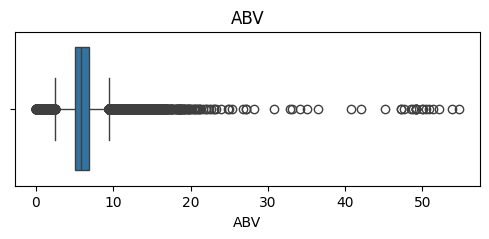

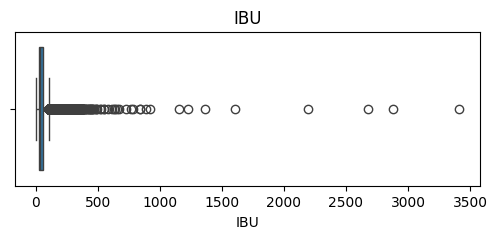

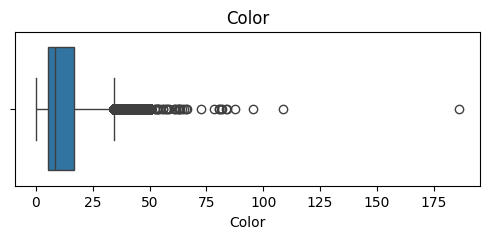

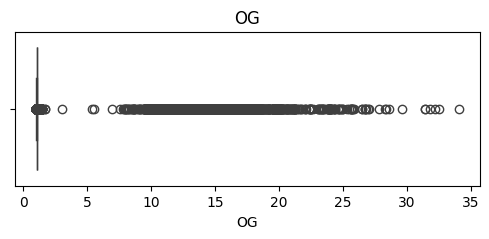

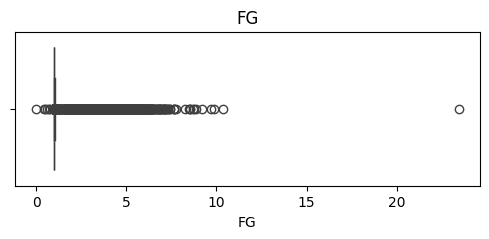

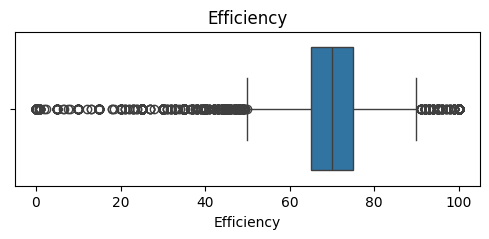

In [58]:
## Detección de outliers y tratamiento usando el método del rango intercuartílico (IQR)

import seaborn as sns
import matplotlib.pyplot as plt

for col in variables:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


for col in variables:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    inferior = Q1 - 1.5 * IQR
    superior = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= inferior) &
        (df[col] <= superior)
    ]



Los valores atípicos fueron identificados mediante el método del rango intercuartílico (IQR) y eliminados para evitar distorsiones en los análisis.

In [59]:
df["Style"].nunique()

174

In [60]:
df["BrewMethod"].value_counts()

BrewMethod
All Grain       37088
BIAB             9404
Partial Mash     1921
extract           804
Name: count, dtype: int64

In [61]:
## Escalado de datos
X = df[variables]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Las variables fueron estandarizadas para evitar que aquellas con escalas mayores dominaran el cálculo de distancias y los componentes principales.

In [62]:
print(df.shape)

df.head()

(49217, 8)


,ABV,IBU,Color,OG,FG,Efficiency,Style,BrewMethod
0,5.48,17.65,4.83,1.055,1.013,70.0,Cream Ale,All Grain
1,8.16,60.65,15.64,1.083,1.021,70.0,Holiday/Winter Special Spiced Beer,All Grain
2,5.91,59.25,8.98,1.063,1.018,70.0,American IPA,extract
3,5.80,54.48,8.50,1.061,1.017,70.0,American IPA,All Grain
4,6.48,17.84,4.57,1.060,1.010,72.0,Belgian Blond Ale,All Grain


**3. INICIO DE PROYECTO**

In [ ]:
## Creamos un nuevo DataFrame con los datos escalados y la variable "Style"
X_scaled_df = pd.DataFrame(X_scaled, index=df.index, columns=variables)
X_scaled_df["Style"] = df["Style"]

## Top 15 estilos más frecuentes
top_estilos = df["Style"].value_counts().nlargest(15).index
X_top = X_scaled_df[X_scaled_df["Style"].isin(top_estilos)]

print("Estilos seleccionados:")
print(df["Style"].value_counts().nlargest(15))

Estilos seleccionados:
Style
American IPA              8390
American Pale Ale         6254
Saison                    2193
American Amber Ale        1588
Blonde Ale                1449
American Light Lager      1392
Irish Red Ale              997
Witbier                    893
American Brown Ale         883
Weissbier                  799
Kölsch                     755
Weizen/Weissbier           751
Cream Ale                  680
California Common Beer     680
English IPA                630
Name: count, dtype: int64


In [65]:
## Escalado de cada variable por estilo
perfil_estilo = X_top.groupby("Style")[variables].mean()

## Distancia euclidiana entre los perfiles de cada estilo
distancias = pd.DataFrame(
    squareform(pdist(perfil_estilo, metric="euclidean")),
    index=perfil_estilo.index,
    columns=perfil_estilo.index
)
distancias.round(2)


Style,American Amber Ale,American Brown Ale,American IPA,American Light Lager,American Pale Ale,Blonde Ale,California Common Beer,Cream Ale,English IPA,Irish Red Ale,Kölsch,Saison,Weissbier,Weizen/Weissbier,Witbier
Style,,,,,,,,,,,,,,,
American Amber Ale,0.00,1.29,1.63,1.03,1.12,1.80,0.67,1.78,1.07,0.67,1.87,1.38,1.85,1.75,1.84
American Brown Ale,1.29,0.00,2.55,2.23,2.40,2.93,1.87,2.92,2.12,1.22,3.02,2.56,2.93,2.83,2.94
American IPA,1.63,2.55,0.00,1.84,1.57,2.55,1.48,2.50,0.70,2.27,2.55,1.77,2.62,2.52,2.59
American Light Lager,1.03,2.23,1.84,0.00,0.63,0.93,0.61,0.81,1.32,1.16,0.96,0.74,0.90,0.80,0.89
American Pale Ale,1.12,2.40,1.57,0.63,0.00,1.02,0.78,1.07,1.08,1.46,1.06,0.88,1.26,1.23,1.23
Blonde Ale,1.80,2.93,2.55,0.93,1.02,0.00,1.46,0.36,2.05,1.77,0.17,1.23,0.61,0.74,0.59
California Common Beer,0.67,1.87,1.48,0.61,0.78,1.46,0.00,1.39,0.86,0.99,1.48,1.12,1.47,1.32,1.41
Cream Ale,1.78,2.92,2.50,0.81,1.07,0.36,1.39,0.00,2.02,1.75,0.32,1.06,0.32,0.44,0.36
English IPA,1.07,2.12,0.70,1.32,1.08,2.05,0.86,2.02,0.00,1.66,2.06,1.49,2.16,2.04,2.10


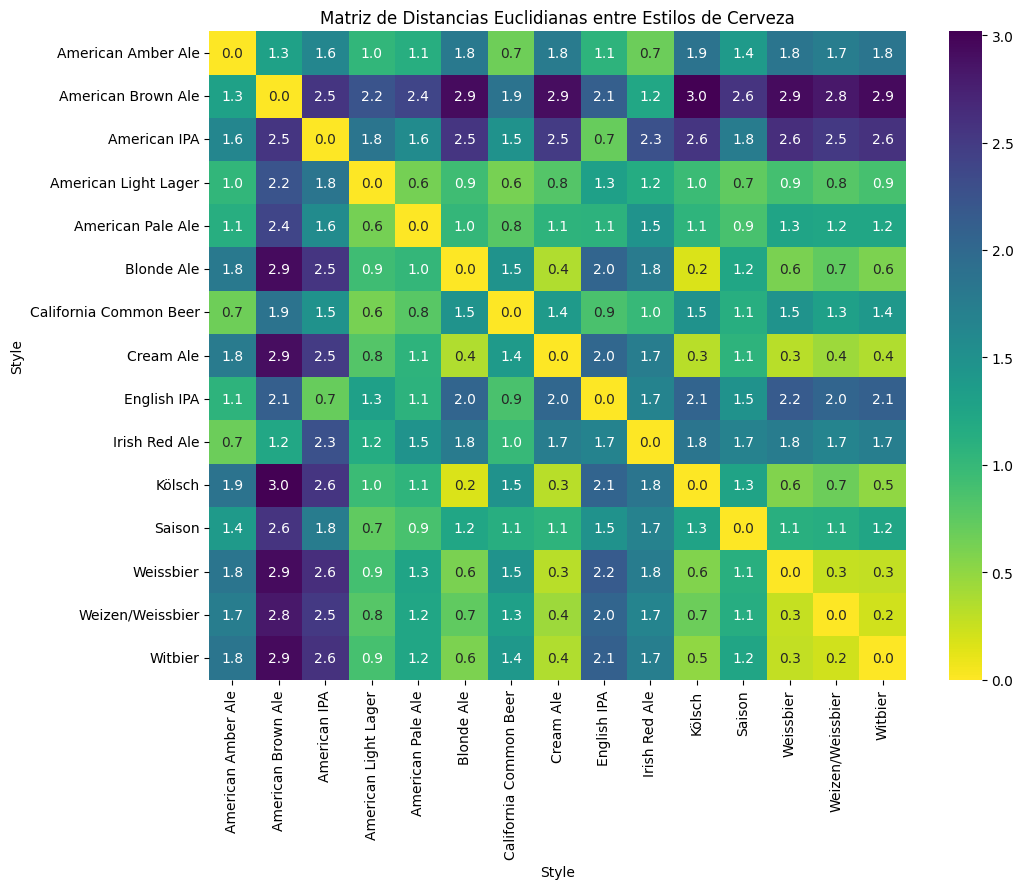

In [66]:
plt.figure(figsize=(11, 9))
sns.heatmap(distancias, annot=True, fmt=".1f", cmap="viridis_r")
plt.title("Matriz de Distancias Euclidianas entre Estilos de Cerveza")
plt.tight_layout()
plt.show()


In [67]:
## Pares de estilos más parecidos (menor distancia) y más distintos (mayor distancia)
d = distancias.where(np.triu(np.ones(distancias.shape), k=1).astype(bool)).stack()

print("Pares de estilos MÁS PARECIDOS:")
print(d.sort_values().head(5))

print("\nPares de estilos MÁS DISTINTOS:")
print(d.sort_values(ascending=False).head(5))


Pares de estilos MÁS PARECIDOS:
Style             Style           
Blonde Ale        Kölsch              0.172071
Weizen/Weissbier  Witbier             0.220053
Weissbier         Weizen/Weissbier    0.267168
                  Witbier             0.272055
Cream Ale         Kölsch              0.319608
dtype: float64

Pares de estilos MÁS DISTINTOS:
Style               Style     
American Brown Ale  Kölsch        3.017692
                    Witbier       2.935833
                    Blonde Ale    2.933061
                    Weissbier     2.932453
                    Cream Ale     2.916077
dtype: float64


Usando la distancia euclidiana sobre el perfil fisicoquímico promedio (escalado) de cada estilo, los estilos más parecidos resultaron ser Blonde Ale y Kölsch (d ≈ 0.17), seguidos de las cervezas de trigo entre sí (Weizen, Witbier, Weissbier). Los más distintos fueron la American Brown Ale frente a las cervezas claras y ligeras, lo que es coherente con su mayor color, cuerpo y amargor. Esto confirma que la distancia euclidiana captura agrupaciones reales por características.

In [68]:
## Correlación de pearson
pares = [("ABV", "IBU"), ("ABV", "OG"), ("IBU", "Color")]

for x, y in pares:
    r, p = pearsonr(df[x], df[y])
    print(f"{x} - {y}:  r = {r:.3f}   p-value = {p:.3e}")


ABV - IBU:  r = 0.367   p-value = 0.000e+00
ABV - OG:  r = 0.951   p-value = 0.000e+00
IBU - Color:  r = 0.020   p-value = 9.766e-06


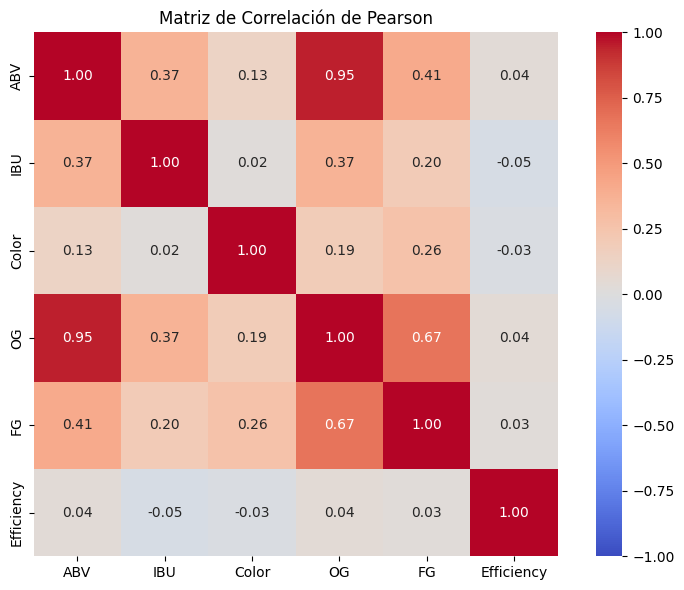

In [69]:
## Matriz de correlación de todas las variables numéricas
corr = df[variables].corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True)
plt.title("Matriz de Correlación de Pearson")
plt.tight_layout()
plt.show()


Existe una correlación muy fuerte y positiva entre ABV y OG (r = 0.95), lo cual es coherente hablando en una parte fisicoquímica: la densidad inicial (azúcares fermentables) determina casi por completo el alcohol producido. 

La relación ABV–IBU es positiva pero débil (r = 0.37): las cervezas más fuertes tienden a ser ligeramente más amargas. 

Finalmente, IBU y Color son prácticamente independientes (r = 0.02), confirmando que el amargor no está ligado al color de la cerveza. 

Aunque todos los p-values son significativos por el gran tamaño muestral, solo ABV–OG representa una relación de magnitud relevante.

In [70]:
## Agrupamos en los 10 estilos más frecuentes + "Otros"
top10 = df["Style"].value_counts().nlargest(10).index
estilo_grupo = df["Style"].where(df["Style"].isin(top10), other="Otros")

## Tabla de Estilo (con la agrupación) vs Método de elaboración
contingencia = pd.crosstab(estilo_grupo, df["BrewMethod"])
contingencia


BrewMethod,All Grain,BIAB,Partial Mash,extract
Style,,,,
American Amber Ale,1214,270,62,42
American Brown Ale,669,166,38,10
American IPA,6348,1590,307,145
American Light Lager,1093,242,44,13
American Pale Ale,4565,1314,255,120
Blonde Ale,1107,273,48,21
Irish Red Ale,756,177,44,20
Otros,18429,4576,985,389
Saison,1657,438,79,19


In [71]:
## Prueba de independencia Chi-cuadrada
chi2, p, dof, esperadas = chi2_contingency(contingencia)

print(f"Chi-cuadrada = {chi2:.2f}")
print(f"p-value      = {p:.3e}")
print(f"Grados de libertad = {dof}")

## Verificamos el supuesto: % de celdas con frecuencia esperada < 5
pct_bajas = (esperadas < 5).mean() * 100
print(f"\nCeldas con frecuencia esperada < 5: {pct_bajas:.1f}%")


Chi-cuadrada = 74.17
p-value      = 1.315e-05
Grados de libertad = 30

Celdas con frecuencia esperada < 5: 0.0%


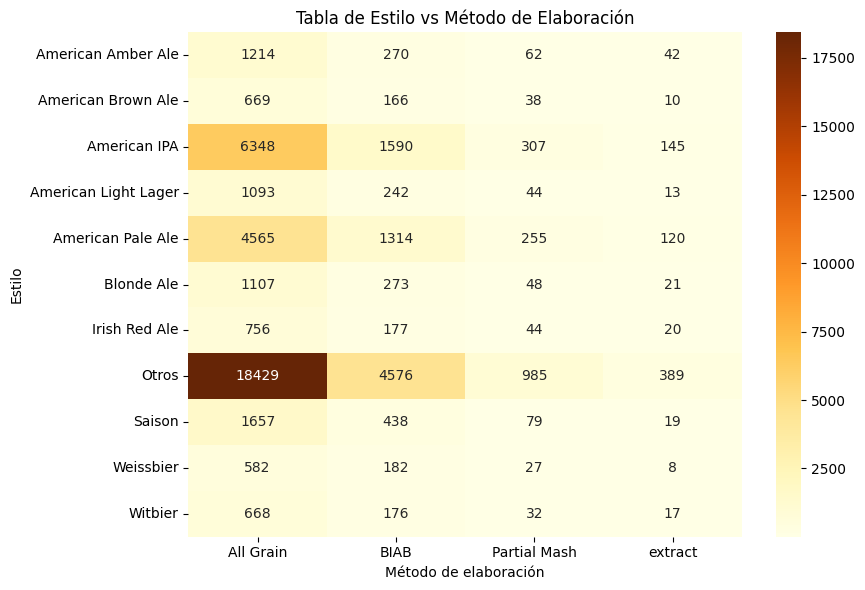

In [73]:
## Visualización de la tabla de estilo vs método de elaboración
plt.figure(figsize=(9, 6))
sns.heatmap(contingencia, annot=True, fmt="d", cmap="YlOrBr")
plt.title("Tabla de Estilo vs Método de Elaboración")
plt.ylabel("Estilo")
plt.xlabel("Método de elaboración")
plt.tight_layout()
plt.show()


Chi-cuadrada (Style vs BrewMethod): Con un estadístico χ² = 74.17 y un p-value = 1.3×10⁻⁵ (< 0.05), se rechaza la hipótesis nula de independencia. Por lo tanto, existe una relación de dependencia entre el estilo de cerveza y el método de elaboración: la elección del método (All Grain, BIAB, extract, Partial Mash) no es uniforme entre estilos. Además, el 0% de celdas con frecuencia esperada menor a 5 confirma que se cumplen los supuestos de la prueba, por lo que el resultado es confiable.

In [74]:
## PCA: reducimos las 6 variables fisicoquímicas a 2 componentes principales
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)
print(f"Varianza total explicada (2 componentes): {pca.explained_variance_ratio_.sum():.4f}")


Varianza explicada por cada componente:
[0.43837629 0.17213644]
Varianza total explicada (2 componentes): 0.6105


In [ ]:
## Guardamos las componentes en el DataFrame
df["PC1"] = componentes[:, 0]
df["PC2"] = componentes[:, 1]

## Cargas
loadings = pd.DataFrame(pca.components_.T, index=variables, columns=["PC1", "PC2"])
loadings.round(3)


,PC1,PC2
ABV,0.549,-0.177
IBU,0.315,-0.477
Color,0.190,0.813
OG,0.599,-0.053
FG,0.452,0.273
Efficiency,0.023,0.045


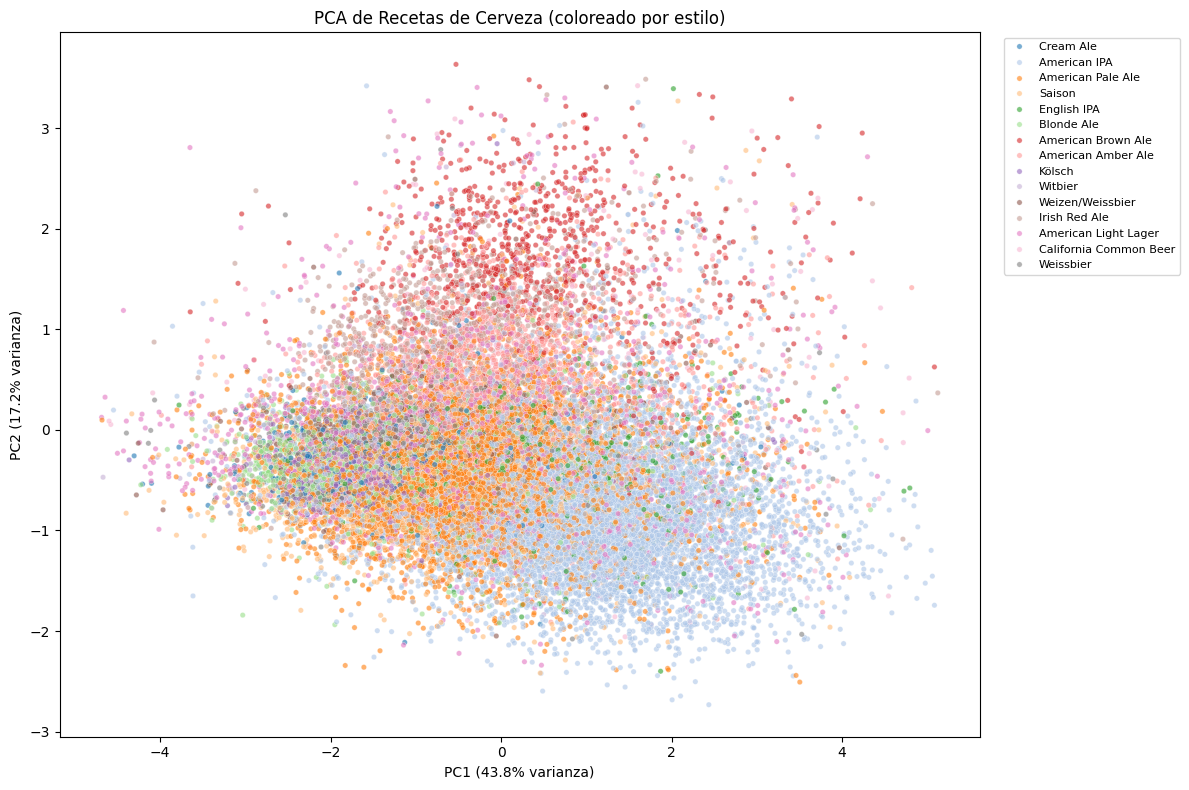

In [76]:
## Visualizamos solo los top 15 estilos para que el gráfico sea legible
df_top = df[df["Style"].isin(top_estilos)]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_top, x="PC1", y="PC2", hue="Style",
                palette="tab20", s=15, alpha=0.6)
plt.title("PCA de Recetas de Cerveza (coloreado por estilo)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


En las dos primeras componentes explican el 61% de la varianza. 
- PC1 (44%) representa la fuerza/cuerpo de la cerveza (OG, ABV, FG) y 
- PC2 (17%) contrapone color frente a amargor (Color vs IBU)

La variable Efficiency no aporta de forma relevante. 

En el espacio de componentes los estilos forman grupos parcialmente identificables: estilos cercanos en el análisis de distancias (cervezas de trigo, rubias suaves) aparecen agrupados, mientras que los estilos robustos y oscuros se ubican en zonas opuestas. Los grupos no están totalmente separados porque varios estilos comparten rangos fisicoquímicos, pero el patrón es coherente con el análisis de similitud. Sí existe una agrupación natural parcial por estilo.

In [78]:
## Guardamos el dataset limpio para el dashboard que se encontrara en "app.py"
df.to_csv("df_limpio.csv", index=False)
print("Dataset guardado:", df.shape)

Dataset guardado: (49217, 10)
